# Software comparison: prot2exon vs every other protein-to-genome tool

This notebook lines prot2exon up **head to head** against every other tool we
could find for mapping protein/domain coordinates to the genome:
`ensembldb::proteinToGenome`, `GenomicFeatures::proteinToGenome`, TransVar, the
Ensembl REST API, VisProDom, and geneplot. It asks two questions of all of them
at once: **do they agree** on the coordinates, and **how fast / how heavy** are
they? Every tool is run on the **same human Ensembl-86 set**; the heavy ones
(ensembldb, REST, TransVar, and VisProDom / geneplot on the human genome) are
measured offline via the scripts in `benchmarks/` rather than inline, since each
takes minutes to hours.

See the [Speed vs other tools](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#speed-vs-other-tools)
wiki section for the comparator-specific notes (why each tool, what each tool's
denominator means, the TransVar envelope-only caveat).

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, re, subprocess
from shutil import which
import pandas as pd
from pathlib import Path

# Set PROT2EXON_REPO / PROT2EXON_DATA to override when running outside a checkout.
start = Path.cwd()
_repo_env = os.environ.get("PROT2EXON_REPO")
REPO = Path(_repo_env) if _repo_env else next(
    (p for p in [start, *start.parents]
     if (p / "benchmarks" / "compare_intervals.py").exists()), start)
DATA = Path(os.environ.get("PROT2EXON_DATA", Path.home() / "Desktop" / "protein2genomic_data"))
V113 = DATA / "validation_v113"     # precomputed REST + TransVar tables (the 5,000-query runs)
V86  = DATA / "validation_v86"
WORK = DATA / "notebook_software_comparison"; WORK.mkdir(parents=True, exist_ok=True)

def clone(url, dest):
    # Clone a tool's repo once (shallow), then reuse it on later runs.
    if not dest.exists():
        subprocess.run(["git", "clone", "--depth", "1", url, str(dest)],
                       check=True, capture_output=True, text=True)
    return dest

# Sections 1-2 use the large-N (5,000-query) tables, which take hours to
# regenerate (ensembldb + the rate-limited REST API), so they are read from
# disk. Sections 4-5 run VisProDom and geneplot live below.
assert (V86  / "table1.tsv").exists(), "run benchmarks/validate_vs_ensembldb.py (see benchmarks/README.md)"
assert (V113 / "rest_table.tsv").exists()
assert (V113 / "transvar_table.tsv").exists()
print("repo:", REPO, "| loaded the precomputed external tables")

repo: /home/goguxor/Desktop/protein2genomic | loaded the precomputed external tables


## 1. Per-tool agreement vs prot2exon

Each external tool answers a slightly different question, so we honour the
differences by reporting both the raw exact-match count **and** the
denominator each tool returned data for. (e.g. TransVar ships an older
Ensembl release than our queries reference, so 3,239 / 5,000 fall into
`only_prot2exon` for it, which is annotation drift, not disagreement.)

In [2]:
def _read_external(path: Path) -> pd.Series:
    # Header line starts with a '#' tool tag; skip it.
    df = pd.read_csv(path, sep="\t", comment="#")
    return df.query("category == 'OVERALL'").iloc[0]

ens   = pd.read_csv(V86 / "table1.tsv", sep="\t").query("category == 'OVERALL'").iloc[0]
rest  = _read_external(V113 / "rest_table.tsv")
tvar  = _read_external(V113 / "transvar_table.tsv")

rows = []
for name, r, denom_col in [
    ("ensembldb", ens, "n"),
    ("TransVar", tvar, "exact_match"),
    ("Ensembl REST", rest, "n"),
]:
    # both-returned denominator: exact + off_by_one + structural
    both = r["exact_match"] + r["off_by_one"] + r["structural_mismatch"]
    if name == "TransVar":
        # TransVar's intersection denominator is documented as 1,761: the
        # queries where TransVar has the ENST in its bundled annotation.
        # exact_match alone gives us that.
        denom = both
    else:
        denom = r["n"] if name == "ensembldb" else both
    pct = 100 * r["exact_match"] / max(1, denom)
    rows.append({"tool": name, "exact_match": int(r["exact_match"]),
                 "denominator": int(denom), "exact_pct": pct,
                 "off_by_one": int(r["off_by_one"]),
                 "only_prot2exon": int(r["only_prot2exon"])})
agree = pd.DataFrame(rows)
agree

,tool,exact_match,denominator,exact_pct,off_by_one,only_prot2exon
0,ensembldb,5000,5000,100.0,0,0
1,TransVar,1761,1761,100.0,0,3239
2,Ensembl REST,983,1000,98.3,17,0


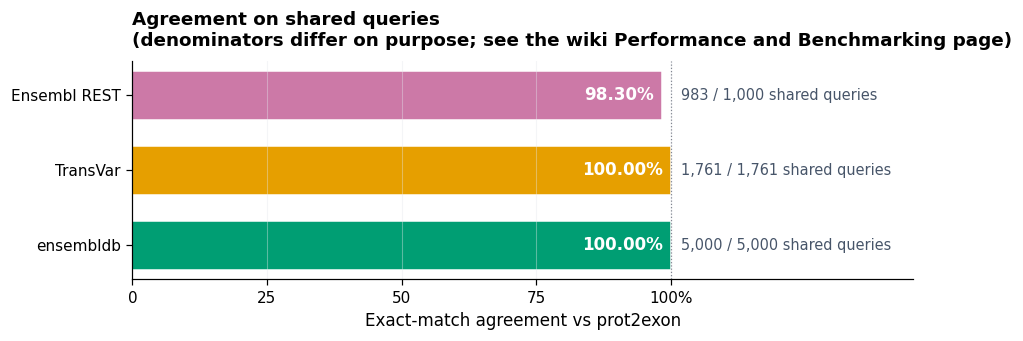

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.2))
palette = [COLORS['ensembldb'], COLORS['transvar'], COLORS['rest']]
bars = ax.barh(agree["tool"], agree["exact_pct"],
               color=palette, edgecolor="white", height=0.65)
for b, r in zip(bars, agree.itertuples()):
    ax.text(102, b.get_y() + b.get_height()/2,
            f"{r.exact_match:,} / {r.denominator:,} shared queries",
            va="center", fontsize=9.5, color="#475569")
    ax.text(r.exact_pct - 1.5, b.get_y() + b.get_height()/2,
            f"{r.exact_pct:.2f}%", va="center", ha="right",
            fontsize=11, fontweight="semibold", color="white")
ax.set_xlim(0, 145)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact-match agreement vs prot2exon")
ax.set_title("Agreement on shared queries\n"
             "(denominators differ on purpose; see the wiki Performance and Benchmarking page)",
             loc='left')
ax.grid(axis='x', alpha=0.4, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

## 2. How fast, and how heavy? Every tool on the same human set

The fair test is to run **every** tool on the **same human v86 query set** and
line up single-thread throughput and peak memory. prot2exon, ensembldb,
GenomicFeatures, TransVar and the Ensembl REST API map human protein-domain
queries directly.

VisProDom and geneplot are general tools (they take any GFF + domain file), so
they go on the human set too, with inputs built from the same Ensembl-86
annotation and Pfam domains (`benchmarks/build_human_tool_inputs.py`, then
`benchmarks/visprodom_human.R` / `benchmarks/geneplot_human.py`). Neither has an
index, and on the human genome that bites: VisProDom rebuilds the whole genome
on every `CreDat` call (**42.7 s, 2.3 GB** for the 1,000-query set), and geneplot
builds a `gffutils` SQLite database of the genome first (minutes) then re-reads
the domain file once per gene (**~14 genes/s**). On their tiny bundled examples
(maize, fruit-fly) both finish in seconds; on real human data they run in
minutes, which is why these two are measured offline rather than inline. All
numbers below are single thread on the same machine and the same human set.

In [4]:
# Every tool on the human Ensembl-86 set, single thread. See benchmarks/ to
# reproduce (proteintogenome_bench.R, run_transvar.py, run_ensembl_rest.py,
# visprodom_human.R, geneplot_human.py).
tools = pd.DataFrame([
    {"tool": "prot2exon",       "per_s": 71429, "rss_mb": 674,          "note": "C++ binary index"},
    {"tool": "TransVar",        "per_s": 1326,  "rss_mb": 284,          "note": "ENST envelope; transvardb + 3 GB FASTA"},
    {"tool": "GenomicFeatures", "per_s": 27,    "rss_mb": 1364,         "note": "in-memory GRanges (R)"},
    {"tool": "VisProDom",       "per_s": 19,    "rss_mb": 2331,         "note": "no index: rebuilds the genome per call (R)"},
    {"tool": "geneplot",        "per_s": 14,    "rss_mb": float('nan'), "note": "gffutils DB + per-gene domain re-read (Python)"},
    {"tool": "ensembldb",       "per_s": 6,     "rss_mb": 1163,         "note": "SQLite EnsDb (R)"},
    {"tool": "Ensembl REST",    "per_s": 1.09,  "rss_mb": float('nan'), "note": "public web API, rate-limited"},
]).sort_values("per_s", ascending=False).reset_index(drop=True)
tools

,tool,per_s,rss_mb,note
0,prot2exon,71429.00,674.0,C++ binary index
1,TransVar,1326.00,284.0,ENST envelope; transvardb + 3 GB FASTA
2,GenomicFeatures,27.00,1364.0,in-memory GRanges (R)
3,VisProDom,19.00,2331.0,no index: rebuilds the genome per call (R)
4,geneplot,14.00,NaN,gffutils DB + per-gene domain re-read (Python)
5,ensembldb,6.00,1163.0,SQLite EnsDb (R)
6,Ensembl REST,1.09,NaN,"public web API, rate-limited"


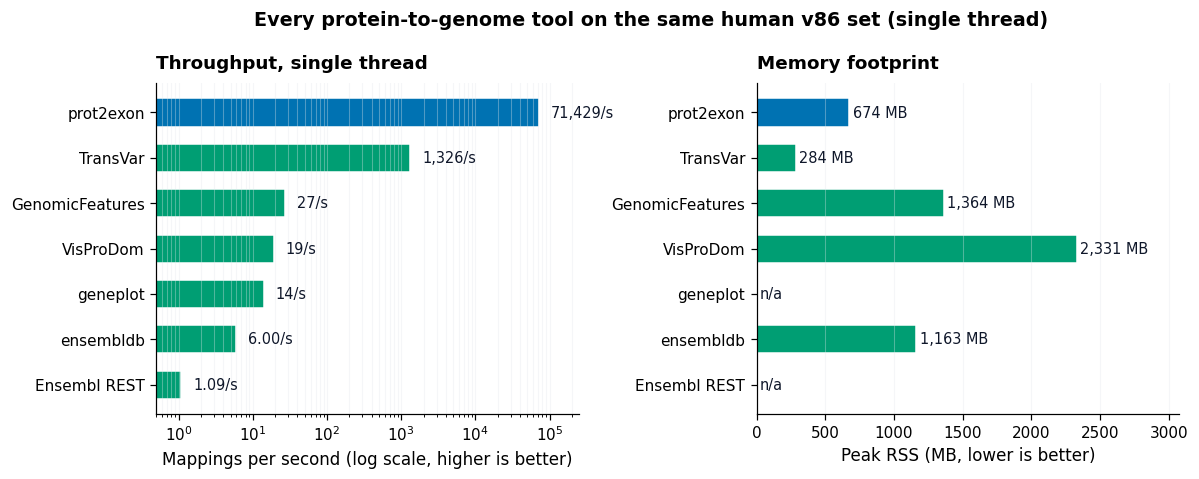

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'wspace': 0.42})
order = tools.iloc[::-1]
colors = [COLORS['prot2exon'] if t == 'prot2exon' else COLORS['ensembldb'] for t in order['tool']]

# Throughput (log scale spans ~1 to ~70,000 per second)
axes[0].barh(order['tool'], order['per_s'], color=colors, edgecolor='white', height=0.62)
axes[0].set_xscale('log'); axes[0].set_xlim(0.5, 250000)
axes[0].set_xlabel('Mappings per second (log scale, higher is better)')
axes[0].set_title('Throughput, single thread', loc='left')
for y, v in enumerate(order['per_s']):
    axes[0].text(v * 1.45, y, (f"{v:,.0f}/s" if v >= 10 else f"{v:.2f}/s"),
                 va='center', fontsize=9.5, color='#0f172a')
axes[0].grid(axis='x', which='both', alpha=0.35, lw=0.7); axes[0].grid(axis='y', visible=False)

# Peak RSS
rss = order['rss_mb'].fillna(0)
axes[1].barh(order['tool'], rss, color=colors, edgecolor='white', height=0.62)
axes[1].set_xlabel('Peak RSS (MB, lower is better)')
axes[1].set_title('Memory footprint', loc='left')
for y, v in enumerate(rss):
    axes[1].text(v + 25, y, (f"{int(v):,} MB" if v > 0 else "n/a"),
                 va='center', fontsize=9.5, color='#0f172a')
axes[1].set_xlim(0, max(rss) * 1.32); axes[1].grid(axis='x', alpha=0.35, lw=0.7); axes[1].grid(axis='y', visible=False)

fig.suptitle("Every protein-to-genome tool on the same human v86 set (single thread)",
             fontsize=12.5, fontweight='semibold', y=1.05)
plt.show()

## What this tells you

- **prot2exon is orders of magnitude faster than every alternative on human
  data.** It maps ~71,000 queries/s; the next-fastest is TransVar at ~1,300/s,
  then everything else is double digits or below: GenomicFeatures ~27/s,
  VisProDom ~19/s, geneplot ~14/s, ensembldb ~6/s, the Ensembl REST API ~1/s.
- **The bundled-example speed was a mirage.** VisProDom and geneplot look quick
  on their small maize / fruit-fly samples (seconds), but on the human genome
  they collapse into the slow-tool range, because neither builds a reusable
  index: VisProDom rebuilds the whole genome on every call, and geneplot rebuilds
  a `gffutils` database and re-reads the domain file per gene. prot2exon pays the
  genome cost once (the index) and then maps in microseconds.
- **And prot2exon agrees with all of them.** It returns identical coordinates to
  ensembldb and GenomicFeatures on the 1,000-query v86 set; TransVar and REST
  agree on the queries they can answer (REST's few misses are codon-boundary
  off-by-ones, see the validation notebook).
- **Memory:** prot2exon uses ~674 MB (the loaded index); the R tools sit at 1.2
  to 2.3 GB. Only prot2exon returns the per-CDS-exon decomposition the wiki's
  [Output description](https://github.com/SotoLF/Prot2Exon/wiki/Mapping#output-description) describes; the others give the genomic envelope only.
- **Scale:** prot2exon runs to 1,000,000 queries (see [`scaling_and_ram.ipynb`](https://github.com/SotoLF/Prot2Exon/blob/main/notebooks/scaling_and_ram.ipynb)); the others cap at 1,000 to 10,000.